<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Image Compression using SVD</b>
</h1>
<div style="font-family:'Times New Roman';">
This is the fun one. An image is just a grid of numbers, so its basically a matrix, which means we can run SVD on it. If we keep only the top k singular values we get a slightly blurry but recognisable image that takes way less storage. Lets see how few singular values we can get away with.
</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cbook as cbook

In [2]:
# matplotlib ships a sample photo so i dont need to download anything
img = plt.imread(cbook.get_sample_data('grace_hopper.jpg'))
print('image shape:', img.shape)   # height, width, 3 colour channels

image shape: (600, 512, 3)


## Turn it into a single matrix

SVD works on a 2d matrix, but the image has 3 colour channels. The simplest thing is to convert it to grayscale by averaging the channels, so we get one clean height by width matrix to work with.

grayscale shape: (600, 512)


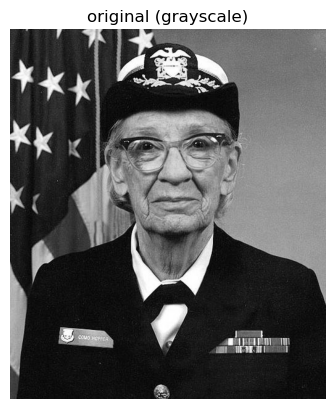

In [3]:
gray = img[:, :, :3].mean(axis=2)
print('grayscale shape:', gray.shape)

plt.imshow(gray, cmap='gray')
plt.title('original (grayscale)')
plt.axis('off')
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Running SVD on the image</b>
</h2>
<div style="font-family:'Times New Roman';">
full_matrices=False gives the economy version which is all we need and is faster. The singular values come out sorted, and if we plot them we can see they drop off really fast, which is exactly why compression works, most of the image is in the first few.
</div>

U: (600, 512)  S: (512,)  Vt: (512, 512)


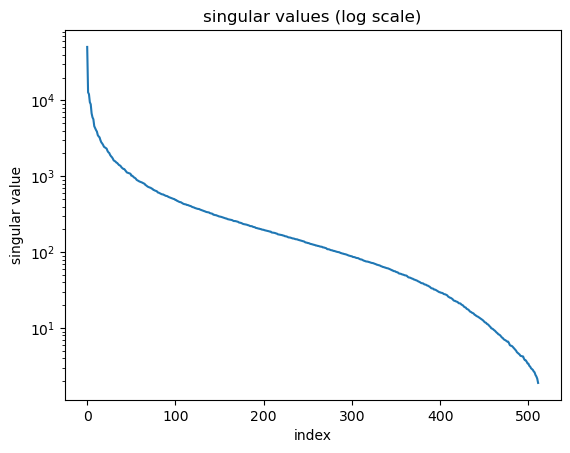

In [4]:
U, S, Vt = np.linalg.svd(gray, full_matrices=False)
print('U:', U.shape, ' S:', S.shape, ' Vt:', Vt.shape)

plt.plot(S)
plt.yscale('log')
plt.title('singular values (log scale)')
plt.xlabel('index')
plt.ylabel('singular value')
plt.show()

In [9]:
def compress(U, S, Vt, k):
    # rebuild the image using only the top k singular values
    return U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]

## Same image at different k

Lets rebuild the photo with a few diffrent values of k and put them side by side with the original.

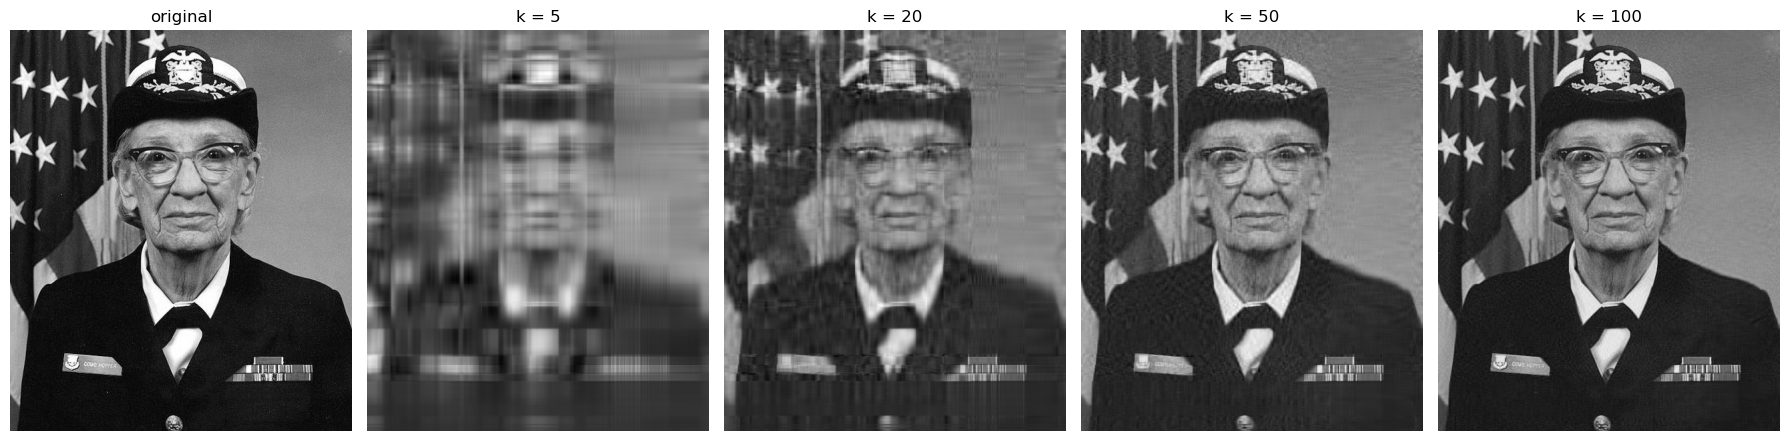

In [6]:
ks = [5, 20, 50, 100]

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title('original')
axes[0].axis('off')

for ax, k in zip(axes[1:], ks):
    ax.imshow(compress(U, S, Vt, k), cmap='gray')
    ax.set_title(f'k = {k}')
    ax.axis('off')

plt.tight_layout()
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>How much space are we actually saving</b>
</h2>
<div style="font-family:'Times New Roman';">
Storing the full image is height times width numbers. With a rank k version we only store the first k columns of U, the first k singular values, and the first k rows of V<sup>T</sup>. That is k times (height + width + 1) numbers. Lets see the ratio.
</div>

In [7]:
m, n = gray.shape
full = m * n

for k in ks:
    stored = k * (m + n + 1)
    print(f'k={k:>3}:  {stored:>7} numbers  ({stored/full*100:.1f}% of the original)')

k=  5:     5565 numbers  (1.8% of the original)
k= 20:    22260 numbers  (7.2% of the original)
k= 50:    55650 numbers  (18.1% of the original)
k=100:   111300 numbers  (36.2% of the original)


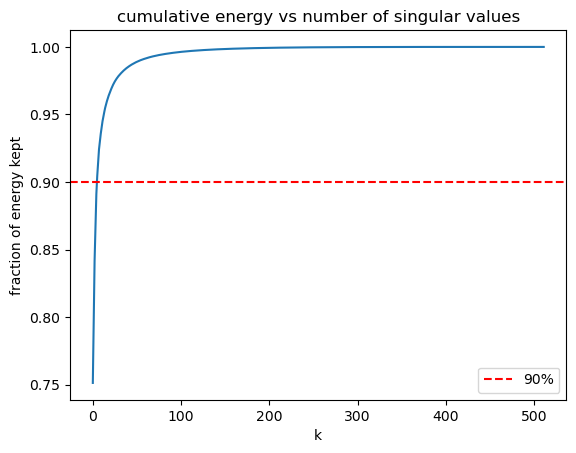

singular values needed for 90% energy: 6


In [8]:
# how much of the image's 'energy' the top k singular values capture
energy = np.cumsum(S**2) / np.sum(S**2)

plt.plot(energy)
plt.axhline(0.9, color='red', linestyle='--', label='90%')
plt.title('cumulative energy vs number of singular values')
plt.xlabel('k')
plt.ylabel('fraction of energy kept')
plt.legend()
plt.show()

print('singular values needed for 90% energy:', np.argmax(energy >= 0.9) + 1)

### what i learned here

- an image is just a matrix so SVD works straight on it
- the singular values drop off fast, so the first few hold most of the picture
- around k=50 the photo already looks basically fine while using a fraction of the storage
- the energy curve is a nice way to pick k, like keep enough singular values for 90% of the energy

thats SVD start to finish, the idea, building it by hand, and using it to squash an image.